In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
from sklearn.datasets import load_wine

In [3]:
#Data collection
wine_data = load_wine()
print(wine_data)

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [4]:
wine_dataframe = pd.DataFrame(data = wine_data.data,columns=wine_data.feature_names)
wine_dataframe["Target"] = wine_data.target
print(wine_data.DESCR)
wine_dataframe

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [5]:
#data understanding
print(wine_dataframe.shape)
print(wine_dataframe.isna().sum())
print(wine_dataframe.describe())
print(wine_dataframe.dtypes)

(178, 14)
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64
          alcohol  malic_acid         ash  ...  od280/od315_of_diluted_wines      proline      Target
count  178.000000  178.000000  178.000000  ...                    178.000000   178.000000  178.000000
mean    13.000618    2.336348    2.366517  ...                      2.611685   746.893258    0.938202
std      0.811827    1.117146    0.274344  ...                      0.709990   314.907474    0.775035
min     11.030000    0.740000    1.360000  ...                      1.270000   278.000000    

In [46]:
#Data processing
X = wine_dataframe.drop("Target",axis=1)
y = wine_dataframe["Target"]
print(X.shape)
print(y.shape)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=9,stratify=y,shuffle=True)
print(X_train.shape,X_test.shape)
standard_scaler = StandardScaler()
scaled_X_train = standard_scaler.fit_transform(X_train)
scaled_X_test = standard_scaler.fit_transform(X_test)
print(scaled_X_train)

(178, 13)
(178,)
(142, 13) (36, 13)
[[ 0.36245403 -0.34510034  1.11035903 ...  0.44110126  0.34087135
   1.64786144]
 [ 1.502656   -0.59287463 -0.28366082 ... -0.11005139  1.01653971
   0.7017464 ]
 [ 0.63217923 -0.50110637  1.00030483 ...  0.56829033  0.38399912
   1.095961  ]
 ...
 [-0.14021566  0.59093586  0.08318651 ... -0.95797854 -1.70050967
  -0.68588898]
 [ 0.33793355  1.77474635 -0.43039975 ... -1.5939239  -1.49924675
   0.27599464]
 [ 0.49731663  2.06840477  1.77068422 ... -1.25475304 -0.98171353
  -0.3705173 ]]


In [40]:
#Model selection
KNN_classifier_test = KNeighborsClassifier()


In [41]:
#Cross validation
Kfold = KFold(n_splits = 5,shuffle=True,random_state=5)
print(Kfold)
cv_score = cross_val_score(KNN_classifier,scaled_X_train,y_train,cv=Kfold)
print(cv_score)

KFold(n_splits=5, random_state=5, shuffle=True)
[0.96551724 0.93103448 0.96428571 0.96428571 1.        ]


In [42]:
accuracy_dictionary = {}
for neighbors in range(3,50,2):
    KNN_classifier = KNeighborsClassifier(n_neighbors=neighbors)
    Kfold = KFold(n_splits = 5,shuffle=True,random_state=5)
    cv_score = cross_val_score(KNN_classifier,scaled_X,y,cv=Kfold)
    accuracy_dictionary.update({neighbors:np.mean(cv_score)})

    

In [43]:
high_accuracy_neighbour  = max(accuracy_dictionary, key=accuracy_dictionary.get)
print(high_accuracy_neighbour)
print(accuracy_dictionary[high_accuracy_neighbour])

31
0.9717460317460318


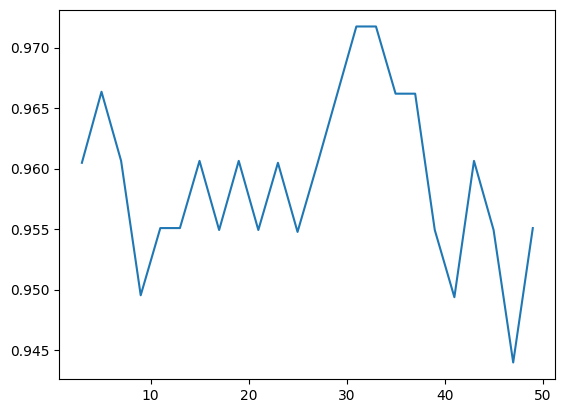

In [44]:
plt.plot(accuracy_dictionary.keys(),accuracy_dictionary.values())

In [ ]:
#Model selection
KNN_classifier = KNeighborsClassifier(n_neighbors=31)

In [45]:
#model training
KNN_classifier.fit(scaled_X_train,y_train)

,n_neighbors,49
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [47]:
#model testing
y_pred_train = KNN_classifier.predict(scaled_X_train)
y_pred_test = KNN_classifier.predict(scaled_X_test)

In [50]:
#model evaluation
print("Accuracy score for training data: ",round(accuracy_score(y_train,y_pred_train),2))
print("Accuracy score for testing data: ",round(accuracy_score(y_test,y_pred_test),2))



Accuracy score for training data:  0.96
Accuracy score for testing data:  1.0
